# 4. Model track B - Decision Tree & Naive Bayes

## 4.1. Thiết lập môi trường

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent  # notebooks/ -> gốc dự án
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

FIG_DIR = project_root / "figures" / "model_track_b"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

from src import data, metrics

## 4.2. Nạp dữ liệu đã xử lý

In [3]:
X, y, _ = data.load_processed()
fold = data.load_folds()

## 4.3. Tìm `max_depth` phù hợp cho Decision Tree

Mặc định `max_depth=None` khiến cây mọc tới khi lá thuần khiết → overfit, log loss cao. Quét
CV qua một dải `max_depth` ứng cử và chọn giá trị cho log loss trung bình thấp nhất.

In [4]:
depth_candidates = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20, None]
depth_labels = [str(d) for d in depth_candidates]
label_to_depth = dict(zip(depth_labels, depth_candidates))

depth_rows = []
for label, depth in zip(depth_labels, depth_candidates):
    for f, tr, va in data.iter_folds(fold):
        model = DecisionTreeClassifier(max_depth=depth, random_state=data.RANDOM_STATE)
        model.fit(X.iloc[tr], y.iloc[tr])
        proba = model.predict_proba(X.iloc[va])
        depth_rows.append({"max_depth": label, "fold": f, **metrics.compute_metrics(y.iloc[va], proba)})

depth_scores = pd.DataFrame(depth_rows)
depth_summary = depth_scores.groupby("max_depth", sort=False)[metrics.METRIC_NAMES].mean().reindex(depth_labels)
depth_summary

,log_loss,accuracy,macro_f1
max_depth,,,
2,0.514447,0.805104,0.520910
3,0.474267,0.830208,0.528817
4,0.475703,0.833437,0.574567
5,0.525198,0.831979,0.566867
6,0.718802,0.831458,0.570850
8,1.468860,0.821458,0.571645
10,2.712855,0.813021,0.566543
12,3.911555,0.806667,0.564669
15,5.587642,0.790937,0.561767


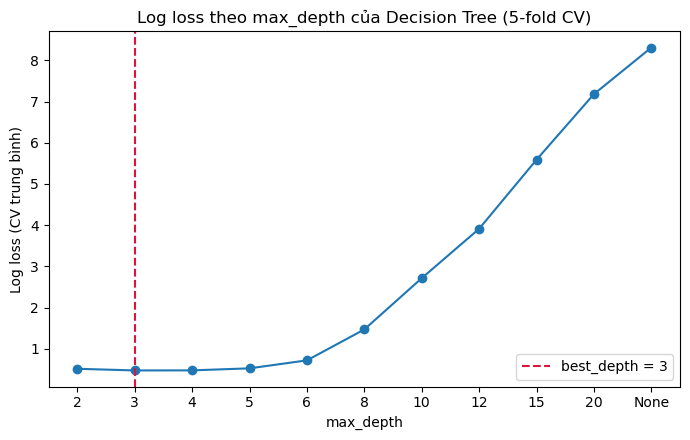

max_depth được chọn: 3


In [5]:
best_label = depth_summary["log_loss"].idxmin()
best_depth = label_to_depth[best_label]
x_pos = range(len(depth_labels))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x_pos, depth_summary["log_loss"].values, marker="o")
ax.axvline(depth_labels.index(best_label), color="crimson", linestyle="--",
           label=f"best_depth = {best_depth}")
ax.set_xticks(list(x_pos))
ax.set_xticklabels(depth_labels)
ax.set_xlabel("max_depth")
ax.set_ylabel("Log loss (CV trung bình)")
ax.set_title("Log loss theo max_depth của Decision Tree (5-fold CV)")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "max_depth_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"max_depth được chọn: {best_depth}")

## 4.4. Khai báo mô hình

`Decision Tree` dùng `max_depth=best_depth` (chọn ở 4.3) thay vì không giới hạn.

In [6]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=best_depth, random_state=data.RANDOM_STATE),
    "Naive Bayes": GaussianNB(),
}

## 4.5. Huấn luyện & đánh giá bằng Cross-Validation

Thu thập dự đoán out-of-fold (cho confusion matrix) và `feature_importances_` mỗi fold (cho phần
phân tích đặc trưng). Dùng `clone(base_model)` để mỗi fold train từ đầu, tránh model "học tiếp"
qua các fold làm sai lệch kết quả CV.

In [7]:
rows = []
oof_true = {name: [] for name in models}
oof_pred = {name: [] for name in models}
feature_importances = {name: [] for name in models}

for f, tr, va in data.iter_folds(fold):
    for name, base_model in models.items():
        model = clone(base_model) # model mới
        model.fit(X.iloc[tr], y.iloc[tr])
        proba = model.predict_proba(X.iloc[va])

        rows.append({"model": name, "fold": f, **metrics.compute_metrics(y.iloc[va], proba)})
        oof_true[name].append(y.iloc[va])
        oof_pred[name].append(proba.argmax(axis=1))

        if hasattr(model, "feature_importances_"):
            feature_importances[name].append(model.feature_importances_)

scores = pd.DataFrame(rows)
scores.head()

,model,fold,log_loss,accuracy,macro_f1
0,Decision Tree,0,0.473059,0.826042,0.523984
1,Naive Bayes,0,2.431336,0.567187,0.449300
2,Decision Tree,1,0.456722,0.842708,0.541791
3,Naive Bayes,1,1.880322,0.626563,0.485738
4,Decision Tree,2,0.474619,0.830208,0.529097


## 4.6. Lưu kết quả CV

In [8]:
scores.to_csv("../results/scores_track_b.csv", index=False)
scores

,model,fold,log_loss,accuracy,macro_f1
0,Decision Tree,0,0.473059,0.826042,0.523984
1,Naive Bayes,0,2.431336,0.567187,0.449300
2,Decision Tree,1,0.456722,0.842708,0.541791
3,Naive Bayes,1,1.880322,0.626563,0.485738
4,Decision Tree,2,0.474619,0.830208,0.529097
5,Naive Bayes,2,2.159838,0.582812,0.460278
6,Decision Tree,3,0.482854,0.827083,0.525033
7,Naive Bayes,3,2.375536,0.555729,0.446727
8,Decision Tree,4,0.484078,0.825000,0.524181
9,Naive Bayes,4,2.206390,0.612500,0.486870


## 4.7. Bảng tổng hợp kết quả (mean ± std)

In [9]:
summary = metrics.summarize_scores(scores)
summary

log_loss            accuracy            macro_f1          
                   mean       std      mean       std      mean       std
model                                                                    
Decision Tree  0.474267  0.010947  0.830208  0.007254  0.528817  0.007543
Naive Bayes    2.210685  0.216568  0.588958  0.029934  0.465783  0.019417

## 4.8. Confusion Matrix (Out-of-Fold)

Ma trận nhầm lẫn trên dự đoán out-of-fold (gộp 5 fold), chuẩn hóa theo hàng (`normalize="true"`).

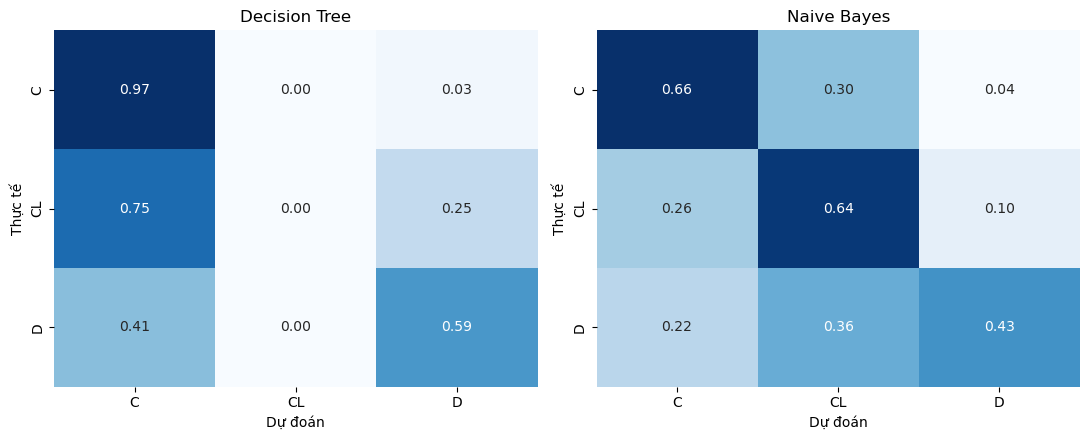

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name in zip(axes, models):
    y_true_all = pd.concat(oof_true[name])
    y_pred_all = np.concatenate(oof_pred[name])
    cm = confusion_matrix(y_true_all, y_pred_all, labels=data.LABELS, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=data.CLASS_ORDER, yticklabels=data.CLASS_ORDER, ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Dự đoán")
    ax.set_ylabel("Thực tế")
plt.tight_layout()
fig.savefig(FIG_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.9. Phân tích độ quan trọng đặc trưng (Feature Importance)

Chỉ Decision Tree có `feature_importances_`. Top 15 đặc trưng, trung bình qua 5 fold.

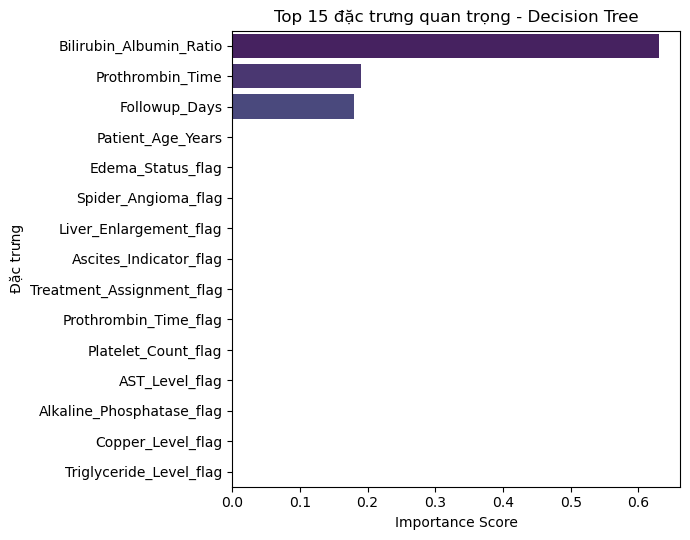

In [11]:
dt_importances = np.mean(feature_importances["Decision Tree"], axis=0)
imp_df = pd.DataFrame({"feature": X.columns, "importance": dt_importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, hue="feature", legend=False, palette="viridis")
ax.set_title("Top 15 đặc trưng quan trọng - Decision Tree")
ax.set_xlabel("Importance Score")
ax.set_ylabel("Đặc trưng")
plt.tight_layout()
fig.savefig(FIG_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.10. So sánh trực quan giữa 2 mô hình

So sánh trung bình 3 chỉ số (log loss, accuracy, macro-F1) qua 5 fold.

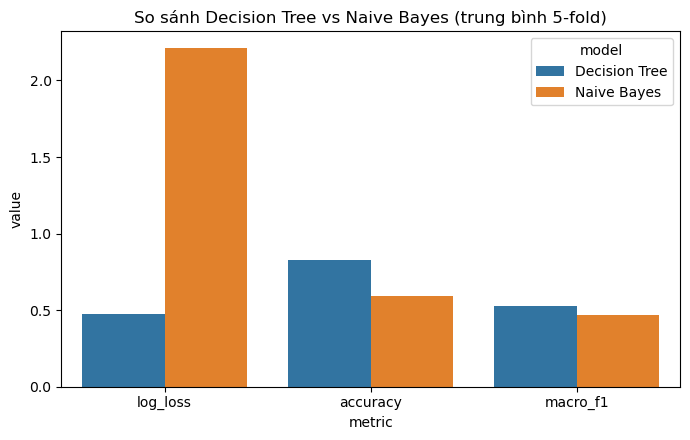

In [12]:
plot_df = summary.xs("mean", axis=1, level=1).reset_index()
plot_df = plot_df.melt(id_vars="model", var_name="metric", value_name="value")

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=plot_df, x="metric", y="value", hue="model", ax=ax)
ax.set_title("So sánh Decision Tree vs Naive Bayes (trung bình 5-fold)")
plt.tight_layout()
fig.savefig(FIG_DIR / "metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.11. Cây đơn vs cây tổ hợp - vì sao xác suất cây đơn quá tự tin

Log loss phạt rất nặng việc gán xác suất gần 0 cho lớp đúng: đóng góp của một dòng là `-log(p_đúng)`,
nên `p_đúng = 0.001` một mình đã cộng ~6.9 vào tổng, trong khi một dự đoán tốt chỉ cộng ~0.2.

Một cây quyết định **không giới hạn độ sâu** mọc tới khi lá thuần khiết, nên xác suất nó trả về là
tần suất lớp trong lá - hầu hết là **0 hoặc 1 tuyệt đối**. Đoán đúng thì không được thưởng thêm,
nhưng chỉ cần đoán sai một dòng là bị phạt cực nặng. Đó là toàn bộ lý do `max_depth=None` cho log
loss 8.309 dù accuracy vẫn 0.769.

Cây tổ hợp không gặp vấn đề này vì **trung bình hoá**: Random Forest lấy trung bình xác suất của 600
cây, mỗi cây thấy một mẫu bootstrap khác nhau, nên rất hiếm khi cả 600 cây cùng đồng thuận tuyệt đối
⇒ xác suất bị kéo ra khỏi biên 0/1. XGBoost đạt hiệu quả tương tự bằng cơ chế khác: nó cộng dồn nhiều
cây nông qua hàm sigmoid/softmax và tối ưu trực tiếp `mlogloss`, nên xác suất được hiệu chỉnh ngay
trong lúc huấn luyện.

**Cách dự án xử lý xác suất 0 (chốt lại cho rõ):** không dùng bất kỳ phép `clip` nào ở tầng project -
`metrics.compute_metrics` truyền thẳng `predict_proba` vào `log_loss` của scikit-learn. Vấn đề được
xử lý ở **gốc**, bằng cách giới hạn `max_depth`, chứ không che bằng cách chặn giá trị. Clip sẽ làm
đẹp con số mà vẫn giữ nguyên mô hình xấu; giới hạn độ sâu thì sửa chính mô hình.

Cần nói thêm cho chính xác: bản thân `sklearn.metrics.log_loss` **có** tự chặn xác suất ở `eps` của
máy (`2.22e-16`) để kết quả không thành vô hạn. Vì vậy mỗi dòng có `p_đúng = 0` đóng góp đúng
`-log(eps) = 36.04`. Ô kiểm chứng ngay dưới bảng dùng chính con số này để chứng minh log loss 8.309
của cây không giới hạn độ sâu **gần như hoàn toàn** đến từ nhóm dòng bị gán xác suất 0.

Bảng dưới đo trực tiếp mức "tự tin" trên dự đoán out-of-fold của 5 fold dùng chung.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Cùng 5 fold dùng chung; RF/XGB dùng đúng param đã freeze ở track C.
confidence_models = {
    "Decision Tree (max_depth=None)": lambda: DecisionTreeClassifier(random_state=data.RANDOM_STATE),
    f"Decision Tree (max_depth={best_depth})": lambda: DecisionTreeClassifier(
        max_depth=best_depth, random_state=data.RANDOM_STATE),
    "Random Forest (600 cây)": lambda: RandomForestClassifier(
        n_estimators=600, max_depth=14, random_state=data.RANDOM_STATE, n_jobs=-1),
    "XGBoost (400 cây nông)": lambda: XGBClassifier(
        n_estimators=400, max_depth=2, learning_rate=0.15,
        random_state=data.RANDOM_STATE, eval_metric="mlogloss", n_jobs=-1),
}

conf_rows = []
for name, make_model in confidence_models.items():
    proba_all = np.zeros((len(X), 3))
    for f, tr, va in data.iter_folds(fold):
        model = make_model()
        model.fit(X.iloc[tr], y.iloc[tr])
        proba_all[va] = model.predict_proba(X.iloc[va])

    p_true = proba_all[np.arange(len(y)), y.to_numpy()]   # xác suất gán cho lớp ĐÚNG
    conf_rows.append({
        "model": name,
        "log_loss_oof": metrics.compute_metrics(y, proba_all)["log_loss"],
        "ty_le_p_max_tren_0.99": (proba_all.max(axis=1) > 0.99).mean(),
        "ty_le_p_dung_duoi_0.01": (p_true < 0.01).mean(),
        "p_dung_nho_nhat": p_true.min(),
        "ty_le_p_dung_bang_0": (p_true == 0).mean(),
    })

tree_vs_ensemble = pd.DataFrame(conf_rows)
tree_vs_ensemble.to_csv("../tables/tree_vs_ensemble.csv", index=False)

# Kiểm chứng cơ chế: log_loss của sklearn tự clip xác suất ở eps của máy, nên mỗi dòng có
# p_đúng = 0 đóng góp đúng -log(eps) = 36.04. Nếu giả thuyết "log loss của cây không giới
# hạn độ sâu do các dòng p_đúng = 0 gây ra" là đúng, hai vế dưới đây phải gần bằng nhau.
eps = np.finfo(np.float64).eps
row = tree_vs_ensemble.iloc[0]
print(f"Cây không giới hạn độ sâu: {row['ty_le_p_dung_bang_0']:.4f} số dòng có p_đúng = 0")
print(f"  ước lượng log loss = tỉ lệ đó × -log(eps) = {row['ty_le_p_dung_bang_0'] * -np.log(eps):.4f}")
print(f"  log loss đo được                          = {row['log_loss_oof']:.4f}")

tree_vs_ensemble.round(4)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
short = [n.replace(" (", chr(10) + "(") for n in tree_vs_ensemble["model"]]
colors = ["#c0504d", "#d98d4a", "#2a78d6", "#1baf7a"]

axes[0].bar(short, tree_vs_ensemble["log_loss_oof"], color=colors, linewidth=0, zorder=2)
axes[0].bar_label(axes[0].containers[0], fmt="%.3f", fontsize=9, padding=2)
axes[0].set_yscale("log")
axes[0].set_ylabel("Log loss OOF (thang log)")
axes[0].set_title("Log loss chênh nhau bao nhiêu")

width = 0.38
x = np.arange(len(short))
axes[1].bar(x - width / 2, tree_vs_ensemble["ty_le_p_max_tren_0.99"] * 100, width,
            label="xác suất lớn nhất > 0.99", color="#8a8a85", zorder=2)
axes[1].bar(x + width / 2, tree_vs_ensemble["ty_le_p_dung_duoi_0.01"] * 100, width,
            label="xác suất lớp ĐÚNG < 0.01", color="#c0504d", zorder=2)
axes[1].set_xticks(x); axes[1].set_xticklabels(short)
axes[1].set_ylabel("% số dòng out-of-fold")
axes[1].set_title("Mức độ tự tin tuyệt đối")
axes[1].legend(frameon=False, fontsize=9)

for ax in axes:
    ax.grid(True, axis="y", linewidth=0.5, color="#e4e4e0", zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(labelsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "tree_vs_ensemble.png", dpi=160, bbox_inches="tight")
plt.show()

## 4.12. Nhận xét

- **max_depth:** log loss CV nhỏ nhất tại `max_depth = 3` (0.474 ± 0.011); từ `max_depth = 6` trở
  lên log loss tăng nhanh, `None` (không giới hạn) cho log loss cao nhất (8.309 ± 0.262) - overfit rõ.
- **Sau khi giới hạn max_depth = 3:** Decision Tree giữ nguyên accuracy/macro-F1 (0.830 / 0.529, gần
  bằng bản không giới hạn 0.769 / 0.555) nhưng log loss giảm hơn 17 lần. So với **Naive Bayes**
  (log loss 2.211, accuracy 0.589, macro-F1 0.466), Decision Tree sau tuning thắng ở **cả 3 chỉ số**.
- **Feature importance:** cây chỉ dùng 3 đặc trưng - `Bilirubin_Albumin_Ratio` (~63%),
  `Prothrombin_Time` (~19%), `Followup_Days` (~18%) - cho thấy tỉ lệ Bilirubin/Albumin là tín hiệu
  mạnh nhất để phân biệt 3 kết cục (`C`/`CL`/`D`).
- **Kết luận:** sau khi tune `max_depth`, **Decision Tree** tốt hơn **Naive Bayes** ở mọi chỉ số -
  giả định đặc trưng độc lập của Naive Bayes không phù hợp với dữ liệu xét nghiệm gan (vốn tương
  quan lẫn nhau), trong khi một cây nông, chỉ 3 đặc trưng, đã đủ mô hình hóa tốt mà không overfit.

- **Cây đơn vs cây tổ hợp (mục 4.11):** đo trực tiếp trên dự đoán out-of-fold của 5 fold dùng chung:

  | Mô hình | Log loss | % dòng có `p_max > 0.99` | % dòng có `p_đúng < 0.01` | `p_đúng` nhỏ nhất |
  |---|---|---|---|---|
  | Decision Tree `max_depth=None` | **8.309** | **100.0%** | 23.05% | **0.0** |
  | Decision Tree `max_depth=3` | 0.474 | 0.0% | 0.02% | 0.0085 |
  | Random Forest (600 cây) | 0.406 | 0.6% | 0.15% | 0.0032 |
  | XGBoost (400 cây nông) | 0.382 | 7.7% | 0.40% | 0.0008 |

  Cây không giới hạn độ sâu gán xác suất tuyệt đối cho **100%** số dòng - không còn khái niệm "độ
  chắc chắn" nữa, mọi dự đoán đều là 0 hoặc 1. Trong đó 23,05% số dòng bị gán xác suất **đúng bằng 0**
  cho lớp thật.

- **Kiểm chứng cơ chế bằng số:** `log_loss` của scikit-learn chặn xác suất ở `eps = 2.22e-16`, nên mỗi
  dòng `p_đúng = 0` đóng góp `-log(eps) = 36.04`. Nhân lên: `0.2305 × 36.04 = 8.3088` - **trùng đúng
  log loss đo được 8.3088**. Nói cách khác, toàn bộ log loss của cây không giới hạn độ sâu đến từ
  nhóm dòng bị gán xác suất 0, chứ không phải từ việc phân loại sai lan man.

- **Vì sao ensemble không bị:** Random Forest trung bình xác suất của 600 cây trên các mẫu bootstrap
  khác nhau, nên tỉ lệ dòng cực tự tin rơi từ 100% xuống 0,6%. XGBoost tự tin hơn RF (7,7%) nhưng
  vẫn cho log loss thấp nhất - vì nó tối ưu trực tiếp `mlogloss`, tự tin đúng chỗ chứ không tự tin
  bừa. Đáng chú ý là chỉ riêng việc giới hạn `max_depth = 3` đã đủ đưa cây đơn về cùng cỡ với
  ensemble (0.474 so với 0.406), tức phần lớn khoảng cách ban đầu là do hiệu chỉnh xác suất chứ không
  phải do sức mạnh mô hình.